
Transfer Function:
   s + 1   
───────────
s⋅(2⋅s + 1)

System:
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    s + 1
  ---------
  2 s^2 + s


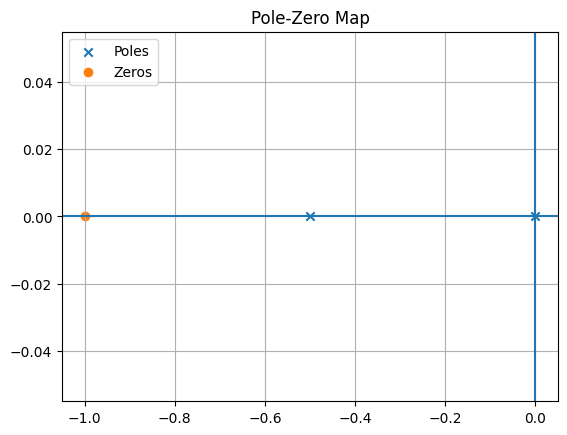

Poles: [-0.5+0.j  0. +0.j]
Zeros: [-1.+0.j]


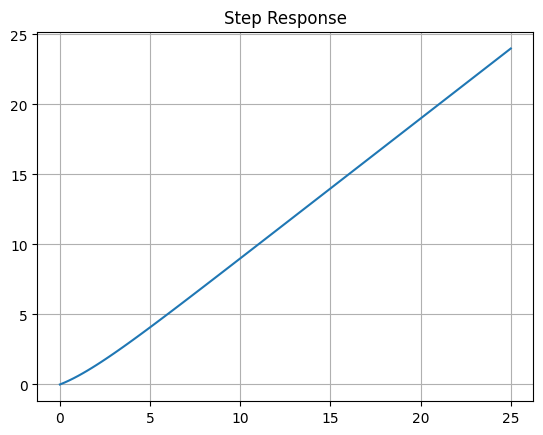

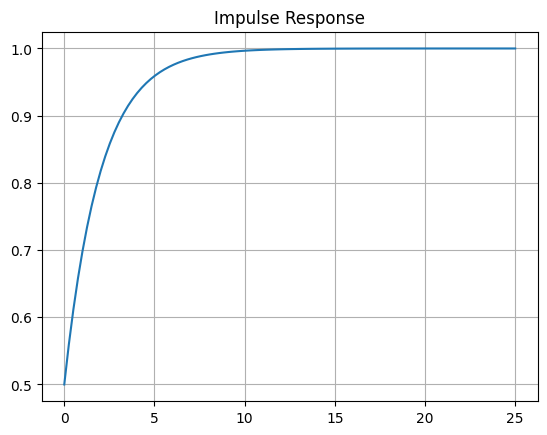

In [3]:
import sympy as sp
import matplotlib.pyplot as plt
import control as ctrl

# symbols
s = sp.symbols('s')
Y, X = sp.symbols('Y X')


# ----------------------------------
# SIMPLE PARSER
# ----------------------------------
def to_laplace(eq):

    eq = eq.replace(" ", "").lower()

    # basic replacements
    eq = eq.replace("d**2*y", "s**2*Y")
    eq = eq.replace("d*y", "s*Y")
    eq = eq.replace("y", "Y")

    eq = eq.replace("d**2*x", "s**2*X")
    eq = eq.replace("d*x", "s*X")
    eq = eq.replace("x", "X")

    return eq


# ----------------------------------
# GET TRANSFER FUNCTION
# ----------------------------------
def get_tf(equation):

    left, right = equation.split("=")

    left = sp.sympify(to_laplace(left))
    right = sp.sympify(to_laplace(right))

    sol = sp.solve(sp.Eq(left, right), Y)[0]

    G = sp.simplify(sol / X)

    return G


# ----------------------------------
# CONVERT TO CONTROL SYSTEM
# ----------------------------------
def to_system(G):

    num, den = sp.fraction(G)

    num = sp.Poly(num, s).all_coeffs()
    den = sp.Poly(den, s).all_coeffs()

    num = [float(i) for i in num]
    den = [float(i) for i in den]

    return ctrl.TransferFunction(num, den)


# ----------------------------------
# PLOT FUNCTIONS
# ----------------------------------
def step_plot(sys):
    t, y = ctrl.step_response(sys)
    plt.plot(t, y)
    plt.title("Step Response")
    plt.grid()
    plt.show()


def impulse_plot(sys):
    t, y = ctrl.impulse_response(sys)
    plt.plot(t, y)
    plt.title("Impulse Response")
    plt.grid()
    plt.show()


def pole_zero(sys):
    p = ctrl.poles(sys)
    z = ctrl.zeros(sys)

    plt.scatter(p.real, p.imag, marker='x', label="Poles")
    plt.scatter(z.real, z.imag, marker='o', label="Zeros")

    plt.axhline(0)
    plt.axvline(0)

    plt.legend()
    plt.title("Pole-Zero Map")
    plt.grid()
    plt.show()

    print("Poles:", p)
    print("Zeros:", z)


# ----------------------------------
# MAIN
# ----------------------------------
while True:

    eq = input("\nEnter equation (or 'exit'): ")

    if eq.lower() == "exit":
        break

    try:
        G = get_tf(eq)

        print("\nTransfer Function:")
        sp.pprint(G)

        sys = to_system(G)

        print("\nSystem:")
        print(sys)

        pole_zero(sys)
        step_plot(sys)
        impulse_plot(sys)

    except:
        print("Invalid format. Try again.")

In [2]:
pip install sympy matplotlib control numpy

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------  6.3/6.3 MB 34.0 MB/s eta 0:00:01
   ---------------------------------------- 6.3/6.3 MB 26.2 MB/s  0:00:00
   ---------------------------------------- 0.0/536.2 kB ? eta -:--:--
   ---------------------------------------- 536.2/536.2 kB 9.7 MB/s  0:00:00

   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   -------------------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Mira\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
